# 01 — Exploratory Data Analysis

Stage 2 (Data Understanding), analysis pass. Builds intuition that drives Stage 3 feature engineering: target behavior, inventory/demand censoring, and pricing patterns.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data.load import read_cleaned

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

df = read_cleaned()
df.shape


(73100, 15)

## 1. Target behavior — `Units Sold`

In [2]:
df["Units Sold"].describe()


count    73100.000000
mean       136.464870
std        108.919406
min          0.000000
25%         49.000000
50%        107.000000
75%        203.000000
max        499.000000
Name: Units Sold, dtype: float64

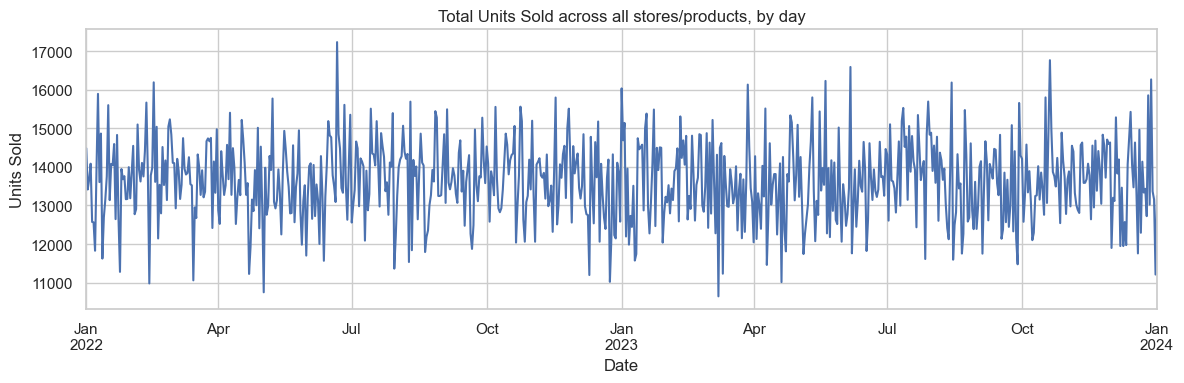

In [3]:
daily_total = df.groupby(config.DATE_COL)["Units Sold"].sum()

fig, ax = plt.subplots(figsize=(12, 4))
daily_total.plot(ax=ax)
ax.set_title("Total Units Sold across all stores/products, by day")
ax.set_ylabel("Units Sold")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "eda_daily_total_units_sold.png", dpi=120)
plt.show()


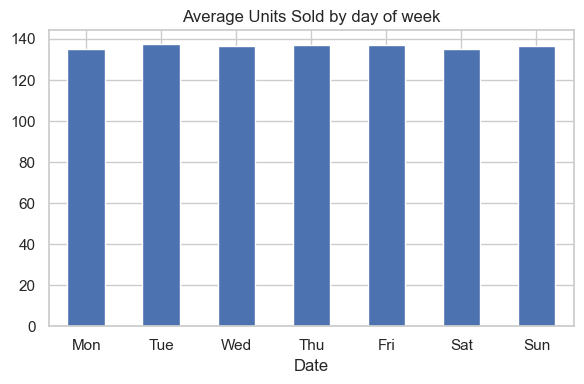

In [4]:
dow_avg = df.groupby(df[config.DATE_COL].dt.dayofweek)["Units Sold"].mean()

fig, ax = plt.subplots(figsize=(6, 4))
dow_avg.plot(kind="bar", ax=ax)
ax.set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], rotation=0)
ax.set_title("Average Units Sold by day of week")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "eda_dow_avg_units_sold.png", dpi=120)
plt.show()


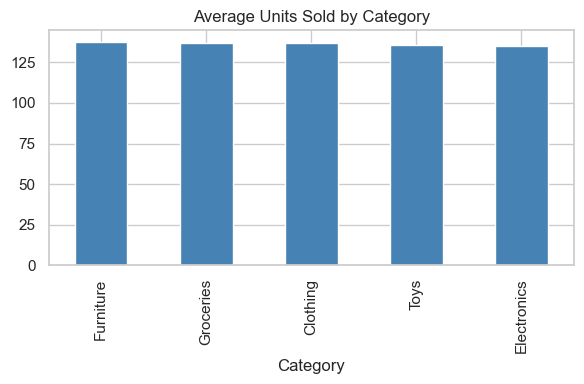

In [5]:
cat_avg = df.groupby("Category", observed=True)["Units Sold"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
cat_avg.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Average Units Sold by Category")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "eda_category_avg_units_sold.png", dpi=120)
plt.show()


In [6]:
promo_effect = df.groupby("Holiday/Promotion")["Units Sold"].mean()
print("Avg Units Sold, no promo vs promo/holiday:")
print(promo_effect)

weather_effect = df.groupby("Weather Condition", observed=True)["Units Sold"].mean().sort_values(ascending=False)
print("\nAvg Units Sold by Weather Condition:")
print(weather_effect)


Avg Units Sold, no promo vs promo/holiday:
Holiday/Promotion
0    136.505375
1    136.423926
Name: Units Sold, dtype: float64

Avg Units Sold by Weather Condition:
Weather Condition
Sunny     138.028650
Cloudy    136.758324
Snowy     135.911559
Rainy     135.160028
Name: Units Sold, dtype: float64


## 2. `Demand Forecast` column vs actual `Units Sold`

The dataset ships its own `Demand Forecast` column. We treat it strictly as an external benchmark to beat later in Challenge 1 — never as a feature (that would leak a competing forecast into our own model).

In [7]:
corr = df[["Units Sold", "Demand Forecast"]].corr().iloc[0, 1]
err = (df["Demand Forecast"] - df["Units Sold"])
print(f"corr(Units Sold, Demand Forecast) = {corr:.3f}")
print(f"mean error (Demand Forecast - Units Sold) = {err.mean():.2f}, MAE = {err.abs().mean():.2f}")


corr(Units Sold, Demand Forecast) = 0.997
mean error (Demand Forecast - Units Sold) = 5.03, MAE = 8.34


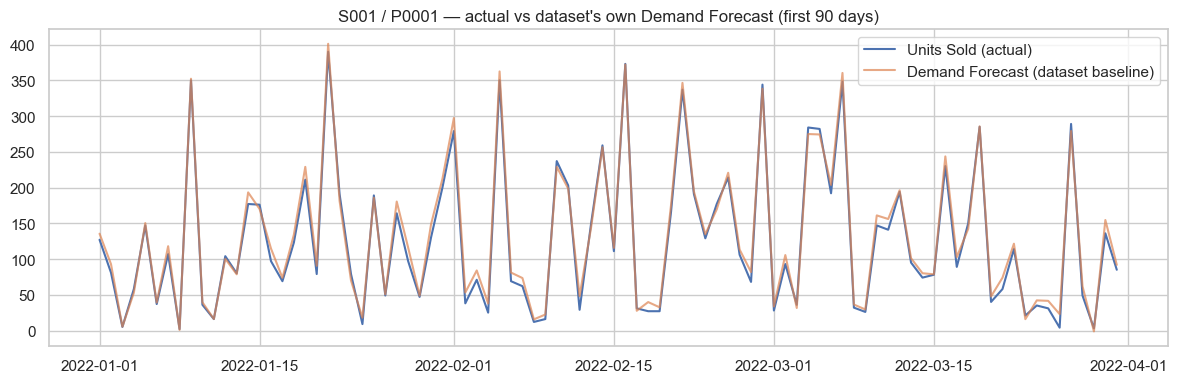

In [8]:
sample = df[(df["Store ID"] == "S001") & (df["Product ID"] == "P0001")].sort_values(config.DATE_COL).head(90)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sample[config.DATE_COL], sample["Units Sold"], label="Units Sold (actual)")
ax.plot(sample[config.DATE_COL], sample["Demand Forecast"], label="Demand Forecast (dataset baseline)", alpha=0.7)
ax.set_title("S001 / P0001 — actual vs dataset's own Demand Forecast (first 90 days)")
ax.legend()
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "eda_demand_forecast_vs_actual.png", dpi=120)
plt.show()


## 3. Inventory behavior & potential demand censoring

If `Units Sold` is close to `Inventory Level` on a given day, the stock may have run out and the true (uncensored) demand could have been higher. Flagging this now so it's carried as an explicit caveat into Challenge 1/2 modeling.

In [9]:
near_stockout = (df["Units Sold"] >= 0.95 * df["Inventory Level"]) & (df["Inventory Level"] > 0)
zero_stock = df["Inventory Level"] == 0

print(f"rows where Units Sold >= 95% of Inventory Level: {near_stockout.sum()} ({near_stockout.mean()*100:.2f}%)")
print(f"rows with Inventory Level == 0: {zero_stock.sum()} ({zero_stock.mean()*100:.2f}%)")


rows where Units Sold >= 95% of Inventory Level: 3752 (5.13%)
rows with Inventory Level == 0: 0 (0.00%)


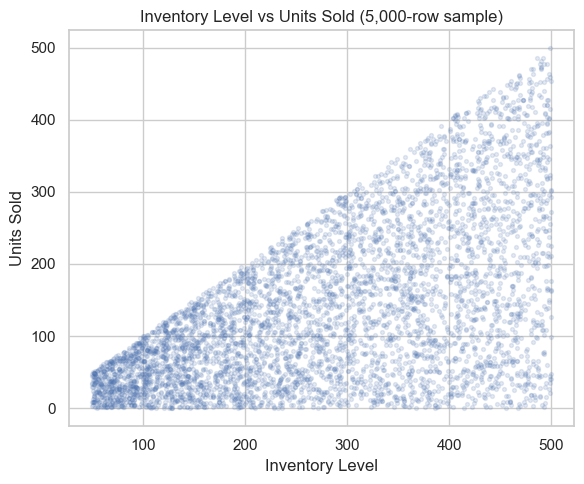

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
sample_corr = df.sample(5000, random_state=config.RANDOM_SEED)
ax.scatter(sample_corr["Inventory Level"], sample_corr["Units Sold"], alpha=0.15, s=8)
ax.set_xlabel("Inventory Level")
ax.set_ylabel("Units Sold")
ax.set_title("Inventory Level vs Units Sold (5,000-row sample)")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "eda_inventory_vs_units_sold.png", dpi=120)
plt.show()


## 4. Pricing behavior

`Price` vs `Competitor Pricing` gap, and `Discount` vs `Units Sold` relationship, by Category — directly informs the Challenge 3 elasticity model's feature set.

count    73100.000000
mean         0.008672
std          0.099518
min         -0.327781
25%         -0.043535
50%          0.000000
75%          0.047243
max          0.992048
Name: price_gap_pct, dtype: float64


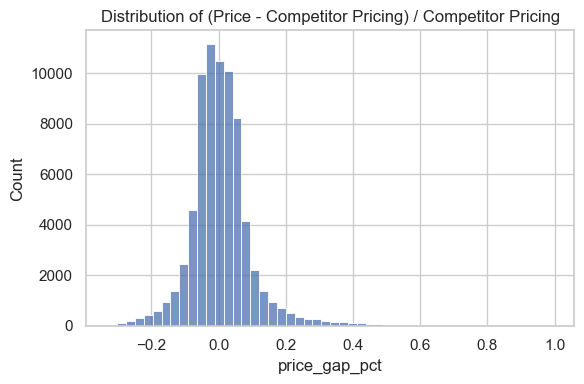

In [11]:
df["price_gap_pct"] = (df["Price"] - df["Competitor Pricing"]) / df["Competitor Pricing"]
print(df["price_gap_pct"].describe())

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df["price_gap_pct"], bins=50, ax=ax)
ax.set_title("Distribution of (Price - Competitor Pricing) / Competitor Pricing")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "eda_price_gap_pct.png", dpi=120)
plt.show()


Discount
(-1, 0]     135.694585
(0, 10]     136.668339
(10, 20]    136.648011
Name: Units Sold, dtype: float64


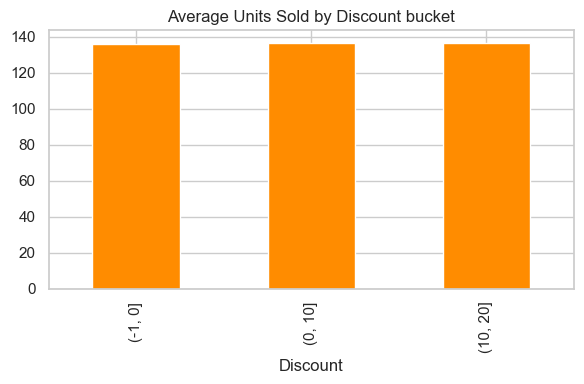

In [12]:
discount_bins = pd.cut(df["Discount"], bins=[-1, 0, 10, 20, 30, 100])
discount_effect = df.groupby(discount_bins, observed=True)["Units Sold"].mean()
print(discount_effect)

fig, ax = plt.subplots(figsize=(6, 4))
discount_effect.plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Average Units Sold by Discount bucket")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "eda_discount_effect.png", dpi=120)
plt.show()


In [13]:
cat_price_corr = (
    df.groupby("Category", observed=True)
    .apply(lambda g: g["Discount"].corr(g["Units Sold"]), include_groups=False)
    .rename("corr(Discount, Units Sold)")
)
cat_price_corr.sort_values(ascending=False)


Category
Electronics    0.016071
Furniture      0.006950
Clothing       0.000461
Toys          -0.004633
Groceries     -0.005864
Name: corr(Discount, Units Sold), dtype: float64

## 5. Representative series for later notebooks

Pick a few (Store, Product) series spanning high/low volume and different categories to use as running examples in the forecasting/inventory/pricing notebooks.

In [14]:
series_volume = df.groupby(config.ID_COLS, observed=True)["Units Sold"].sum().sort_values(ascending=False)
print("Highest-volume series:")
print(series_volume.head(3))
print("\nLowest-volume series:")
print(series_volume.tail(3))


Highest-volume series:
Store ID  Product ID
S005      P0015         109099
S003      P0013         107479
S002      P0001         105999
Name: Units Sold, dtype: int64

Lowest-volume series:
Store ID  Product ID
S004      P0018         94023
S001      P0012         93854
S003      P0003         92556
Name: Units Sold, dtype: int64


## EDA summary

- Weekly seasonality is visible in average Units Sold by day of week; Category and Weather Condition also shift the average.
- The dataset's own `Demand Forecast` correlates with actual `Units Sold` but has non-trivial error — a legitimate baseline to beat, not a feature.
- A measurable share of rows have Units Sold at or near Inventory Level, consistent with possible demand censoring during stockouts — carried forward as an explicit modeling caveat.
- Price gap vs competitors and Discount both show visible relationships with Units Sold, by Category — supports the planned log-log elasticity features in Challenge 3.
- Representative high/low-volume series identified for use as running examples in later notebooks.